In [ ]:
#install kaggle
!pip install -q kaggle

In [ ]:
# Rename uploaded file
!mv "kaggle (1).json" kaggle.json

In [ ]:
#permission for the json to act
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#list all the datrabase in kaggle
! kaggle datasets list

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sadiajavedd/students-academic-performance-dataset               Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           5090        123  1.0              
ayeshaimran123/social-media-and-mental-health-balance           Social Media and Mental Health Balance                    5941  2025-10-26 07:51:53.380000           5714         82  1.0              
shahzadi786/world-smartphone-market-2025                        World Smartphone Market 2025                             17795  2025-11-09 04:52:42.650000           2093         65  1.0              


In [ ]:
! kaggle datasets download -d feyzazkefe/trashnet

Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet
License(s): unknown
  0% 0.00/40.8M [00:00<?, ?B/s]
100% 40.8M/40.8M [00:00<00:00, 1.37GB/s]


In [ ]:
! unzip trashnet.zip

Archive:  trashnet.zip
  inflating: dataset-resized/cardboard/cardboard1.jpg  
  inflating: dataset-resized/cardboard/cardboard10.jpg  
  inflating: dataset-resized/cardboard/cardboard100.jpg  
  inflating: dataset-resized/cardboard/cardboard101.jpg  
  inflating: dataset-resized/cardboard/cardboard102.jpg  
  inflating: dataset-resized/cardboard/cardboard103.jpg  
  inflating: dataset-resized/cardboard/cardboard104.jpg  
  inflating: dataset-resized/cardboard/cardboard105.jpg  
  inflating: dataset-resized/cardboard/cardboard106.jpg  
  inflating: dataset-resized/cardboard/cardboard107.jpg  
  inflating: dataset-resized/cardboard/cardboard108.jpg  
  inflating: dataset-resized/cardboard/cardboard109.jpg  
  inflating: dataset-resized/cardboard/cardboard11.jpg  
  inflating: dataset-resized/cardboard/cardboard110.jpg  
  inflating: dataset-resized/cardboard/cardboard111.jpg  
  inflating: dataset-resized/cardboard/cardboard112.jpg  
  inflating: dataset-resized/cardboard/cardboard113.j

In [ ]:
!ls

 cardboard.jpg	  'kaggle (1) (1).json'   sample_data
 dataset-resized   kaggle.json		  trashnet.zip


In [ ]:
import os
base_dir = 'dataset-resized'
print("folder inside dataset")
print(os.listdir(base_dir))



folder inside dataset
['trash', 'cardboard', 'glass', 'metal', 'plastic', 'paper']


In [ ]:
!ls -la

total 41868
drwxr-xr-x 1 root root     4096 Nov 16 15:27  .
drwxr-xr-x 1 root root     4096 Nov 16 14:45  ..
-rw-r--r-- 1 root root    18295 Nov 16 14:46  cardboard.jpg
drwxr-xr-x 4 root root     4096 Nov 12 14:30  .config
drwxr-xr-x 8 root root     4096 Nov 16 15:27  dataset-resized
-rw-r--r-- 1 root root       72 Nov 16 15:23 'kaggle (1) (1).json'
-rw-r--r-- 1 root root       72 Nov 16 15:27  kaggle.json
drwxr-xr-x 1 root root     4096 Nov 12 14:30  sample_data
-rw-r--r-- 1 root root 42822633 Nov 19  2021  trashnet.zip


In [ ]:
!ls dataset-resized

cardboard  glass  metal  paper	plastic  trash


In [ ]:
import os
base_dir = '/content/dataset-resized'  # exact folder path

folders = os.listdir(base_dir)
print("Folders inside dataset:")
print(folders)

# Count images
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path):
        print(folder, "->", len(os.listdir(folder_path)), "images")

Folders inside dataset:
['trash', 'cardboard', 'glass', 'metal', 'plastic', 'paper']
trash -> 137 images
cardboard -> 403 images
glass -> 501 images
metal -> 410 images
plastic -> 482 images
paper -> 594 images


In [ ]:
import os

# Point to the folder containing class folders
base_dir = '/content/dataset-resized'  # change if your path is different
folders = os.listdir(base_dir)
print("Folders inside dataset:", folders)

Folders inside dataset: ['trash', 'cardboard', 'glass', 'metal', 'plastic', 'paper']


In [ ]:
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path):
        print(folder, "->", len(os.listdir(folder_path)), "images")

trash -> 137 images
cardboard -> 403 images
glass -> 501 images
metal -> 410 images
plastic -> 482 images
paper -> 594 images


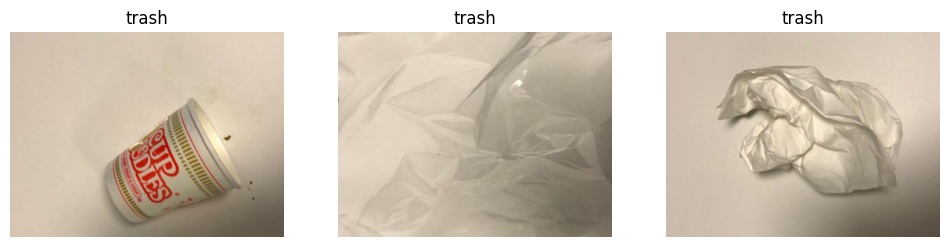

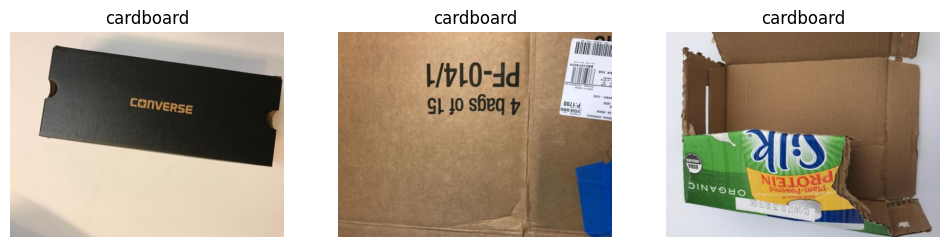

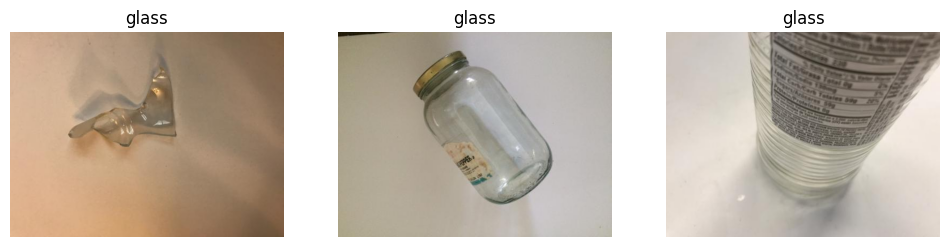

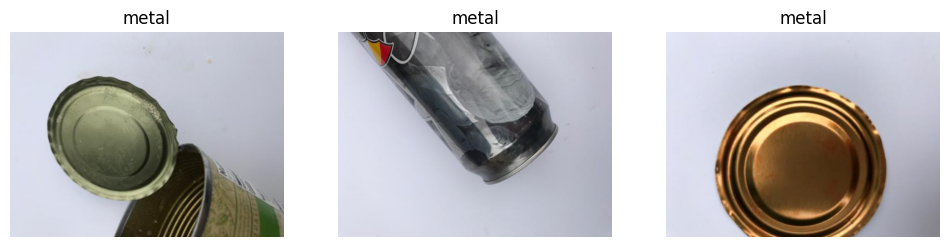

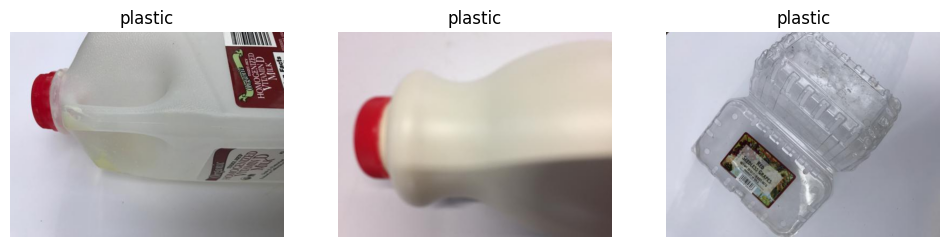

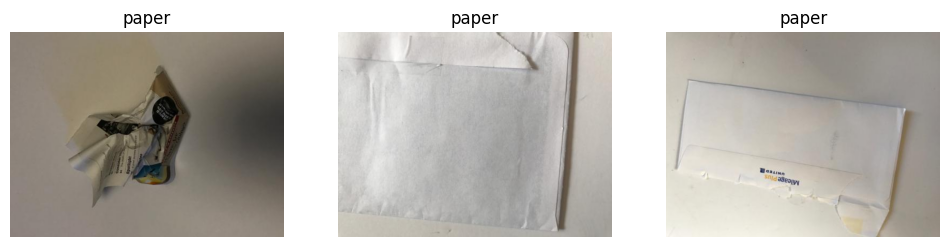

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folders = os.listdir(base_dir)

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    imgs = os.listdir(folder_path)[:3]  # 3 sample images per class

    plt.figure(figsize=(12,4))
    for i, img_name in enumerate(imgs):
        img_path = os.path.join(folder_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(folder)
    plt.show()

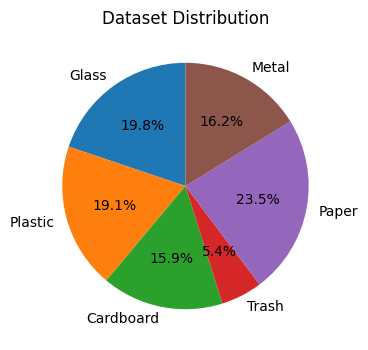

In [ ]:
import matplotlib.pyplot as plt

labels = ['Glass','Plastic','Cardboard','Trash','Paper','Metal']
sizes = [501, 482, 403, 137, 594, 410]

plt.figure(figsize=(4,4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Dataset Distribution')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
!ls /content

 cardboard.jpg	  'kaggle (1) (1).json'   sample_data
 dataset-resized   kaggle.json		  trashnet.zip


In [ ]:
{"filename": "abc.jpg", "label": "cardboard"}

{'filename': 'abc.jpg', 'label': 'cardboard'}

In [ ]:
import zipfile
import os

zip_path = "/content/trashnet.zip"       # your zip file
extract_path = "/content/trash_dataset"  # folder to extract

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check files
!ls /content/trash_dataset

dataset-resized


In [ ]:
import os

base_dir = "/content/dataset-resized"
print("Folders inside dataset:", os.listdir(base_dir))

Folders inside dataset: ['trash', 'cardboard', 'glass', 'metal', 'plastic', 'paper']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# data generators for training and testing
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
#Built CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')  # 6 categories
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.2582 - loss: 1.6974 - val_accuracy: 0.4036 - val_loss: 1.5006
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4457 - loss: 1.3374 - val_accuracy: 0.4294 - val_loss: 1.4392
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.5192 - loss: 1.2388 - val_accuracy: 0.4712 - val_loss: 1.3380
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5932 - loss: 1.0706 - val_accuracy: 0.4632 - val_loss: 1.3479
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6095 - loss: 1.0152 - val_accuracy: 0.5089 - val_loss: 1.3107
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6416 - loss: 0.9537 - val_accuracy: 0.5328 - val_loss: 1.2527
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.6743 - loss: 0.8561 - val_accuracy: 0.5507 - val_loss: 1.2186
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7360 - loss: 0.7322 - val_accuracy: 0.5527 - val_loss: 1.2521
Ep

In [ ]:
model.save("trashnet_model.h5")

In [ ]:
import os
print(os.listdir("/content/dataset-resized/plastic"))

['plastic267.jpg', 'plastic137.jpg', 'plastic330.jpg', 'plastic149.jpg', 'plastic128.jpg', 'plastic202.jpg', 'plastic315.jpg', 'plastic430.jpg', 'plastic144.jpg', 'plastic416.jpg', 'plastic196.jpg', 'plastic305.jpg', 'plastic81.jpg', 'plastic199.jpg', 'plastic338.jpg', 'plastic441.jpg', 'plastic451.jpg', 'plastic262.jpg', 'plastic3.jpg', 'plastic358.jpg', 'plastic103.jpg', 'plastic339.jpg', 'plastic176.jpg', 'plastic273.jpg', 'plastic5.jpg', 'plastic153.jpg', 'plastic384.jpg', 'plastic266.jpg', 'plastic356.jpg', 'plastic395.jpg', 'plastic454.jpg', 'plastic247.jpg', 'plastic86.jpg', 'plastic195.jpg', 'plastic478.jpg', 'plastic239.jpg', 'plastic420.jpg', 'plastic314.jpg', 'plastic477.jpg', 'plastic465.jpg', 'plastic250.jpg', 'plastic389.jpg', 'plastic457.jpg', 'plastic432.jpg', 'plastic418.jpg', 'plastic152.jpg', 'plastic221.jpg', 'plastic412.jpg', 'plastic161.jpg', 'plastic40.jpg', 'plastic13.jpg', 'plastic351.jpg', 'plastic209.jpg', 'plastic4.jpg', 'plastic355.jpg', 'plastic212.jpg', '

In [ ]:
img_path = "/content/dataset-resized/plastic/plastic267.jpg"

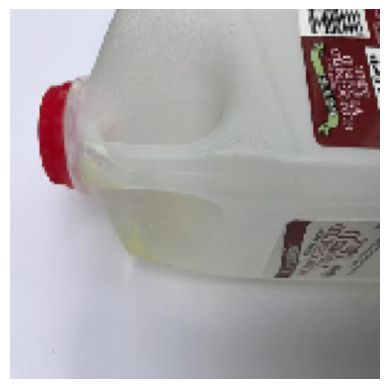

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Category: plastic
♻ Recyclable


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Make sure this path is correct (from Step 2)
# img_path = "/content/dataset-resized/plastic/plastic267.jpg"

# 1. Load the image
img = image.load_img(img_path, target_size=(150,150), color_mode='rgb') # Changed target_size to (150,150)

# 2. Show the image
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Convert to array
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)

# 5. Class list
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]
print("Predicted Category:", predicted_class)

# 6. Recycling logic
recyclable = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
if predicted_class in recyclable:
    print("♻ Recyclable")
else:
    print("❌ Non-recyclable")

In [ ]:
import os
print(os.listdir("/content/dataset-resized/trash"))

['trash50.jpg', 'trash3.jpg', 'trash31.jpg', 'trash9.jpg', 'trash64.jpg', 'trash134.jpg', 'trash38.jpg', 'trash135.jpg', 'trash10.jpg', 'trash40.jpg', 'trash137.jpg', 'trash44.jpg', 'trash4.jpg', 'trash130.jpg', 'trash48.jpg', 'trash120.jpg', 'trash131.jpg', 'trash108.jpg', 'trash54.jpg', 'trash128.jpg', 'trash51.jpg', 'trash49.jpg', 'trash2.jpg', 'trash61.jpg', 'trash71.jpg', 'trash63.jpg', 'trash33.jpg', 'trash124.jpg', 'trash75.jpg', 'trash67.jpg', 'trash102.jpg', 'trash76.jpg', 'trash41.jpg', 'trash93.jpg', 'trash118.jpg', 'trash29.jpg', 'trash107.jpg', 'trash90.jpg', 'trash18.jpg', 'trash47.jpg', 'trash15.jpg', 'trash126.jpg', 'trash103.jpg', 'trash85.jpg', 'trash24.jpg', 'trash42.jpg', 'trash53.jpg', 'trash133.jpg', 'trash100.jpg', 'trash58.jpg', 'trash30.jpg', 'trash87.jpg', 'trash105.jpg', 'trash35.jpg', 'trash19.jpg', 'trash43.jpg', 'trash13.jpg', 'trash95.jpg', 'trash110.jpg', 'trash20.jpg', 'trash57.jpg', 'trash5.jpg', 'trash94.jpg', 'trash116.jpg', 'trash72.jpg', 'trash14.j

In [ ]:
img_path = "/content/dataset-resized/trash/trash40.jpg"

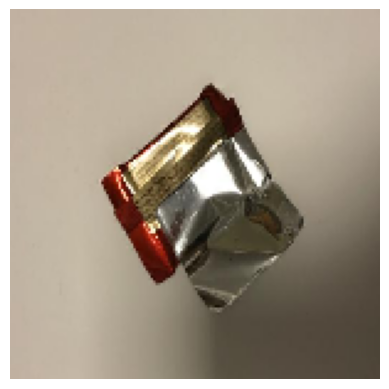

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Predicted Category: trash
❌ Non-recyclable


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Make sure this path is correct (from Step 2)

# 1. Load the image
img = image.load_img(img_path, target_size=(150,150), color_mode='rgb') # Changed target_size to (150,150)

# 2. Show the image
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Convert to array
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)

# 5. Class list
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]
print("Predicted Category:", predicted_class)

# 6. Recycling logic
recyclable = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
if predicted_class in recyclable:
    print("♻ Recyclable")
else:
    print("❌ Non-recyclable")

In [ ]:
import os
print(os.listdir("/content/dataset-resized/glass"))

['glass147.jpg', 'glass169.jpg', 'glass184.jpg', 'glass304.jpg', 'glass423.jpg', 'glass395.jpg', 'glass41.jpg', 'glass486.jpg', 'glass353.jpg', 'glass354.jpg', 'glass456.jpg', 'glass449.jpg', 'glass458.jpg', 'glass472.jpg', 'glass239.jpg', 'glass83.jpg', 'glass289.jpg', 'glass350.jpg', 'glass32.jpg', 'glass69.jpg', 'glass76.jpg', 'glass149.jpg', 'glass11.jpg', 'glass140.jpg', 'glass72.jpg', 'glass249.jpg', 'glass438.jpg', 'glass263.jpg', 'glass137.jpg', 'glass448.jpg', 'glass333.jpg', 'glass340.jpg', 'glass343.jpg', 'glass265.jpg', 'glass143.jpg', 'glass139.jpg', 'glass344.jpg', 'glass284.jpg', 'glass409.jpg', 'glass415.jpg', 'glass467.jpg', 'glass391.jpg', 'glass219.jpg', 'glass20.jpg', 'glass70.jpg', 'glass452.jpg', 'glass10.jpg', 'glass230.jpg', 'glass444.jpg', 'glass96.jpg', 'glass14.jpg', 'glass398.jpg', 'glass64.jpg', 'glass442.jpg', 'glass308.jpg', 'glass292.jpg', 'glass319.jpg', 'glass477.jpg', 'glass91.jpg', 'glass332.jpg', 'glass450.jpg', 'glass266.jpg', 'glass158.jpg', 'glas

In [ ]:
img_path = "/content/dataset-resized/glass/glass423.jpg"

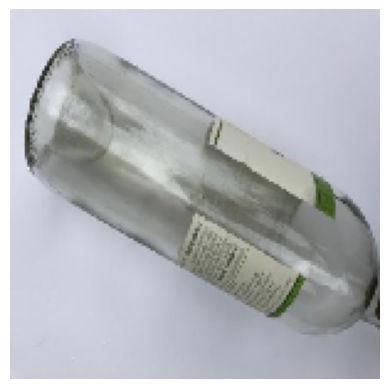

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Category: glass
♻ Recyclable


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Make sure this path is correct (from Step 2)

# 1. Load the image
img = image.load_img(img_path, target_size=(150,150), color_mode='rgb') # Changed target_size to (150,150)

# 2. Show the image
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Convert to array
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)

# 5. Class list
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]
print("Predicted Category:", predicted_class)

# 6. Recycling logic
recyclable = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
if predicted_class in recyclable:
    print("♻ Recyclable")
else:
    print("❌ Non-recyclable")

In [ ]:
import os
print(os.listdir("/content/dataset-resized/glass"))

['glass147.jpg', 'glass169.jpg', 'glass184.jpg', 'glass304.jpg', 'glass423.jpg', 'glass395.jpg', 'glass41.jpg', 'glass486.jpg', 'glass353.jpg', 'glass354.jpg', 'glass456.jpg', 'glass449.jpg', 'glass458.jpg', 'glass472.jpg', 'glass239.jpg', 'glass83.jpg', 'glass289.jpg', 'glass350.jpg', 'glass32.jpg', 'glass69.jpg', 'glass76.jpg', 'glass149.jpg', 'glass11.jpg', 'glass140.jpg', 'glass72.jpg', 'glass249.jpg', 'glass438.jpg', 'glass263.jpg', 'glass137.jpg', 'glass448.jpg', 'glass333.jpg', 'glass340.jpg', 'glass343.jpg', 'glass265.jpg', 'glass143.jpg', 'glass139.jpg', 'glass344.jpg', 'glass284.jpg', 'glass409.jpg', 'glass415.jpg', 'glass467.jpg', 'glass391.jpg', 'glass219.jpg', 'glass20.jpg', 'glass70.jpg', 'glass452.jpg', 'glass10.jpg', 'glass230.jpg', 'glass444.jpg', 'glass96.jpg', 'glass14.jpg', 'glass398.jpg', 'glass64.jpg', 'glass442.jpg', 'glass308.jpg', 'glass292.jpg', 'glass319.jpg', 'glass477.jpg', 'glass91.jpg', 'glass332.jpg', 'glass450.jpg', 'glass266.jpg', 'glass158.jpg', 'glas

In [ ]:
img_path = "/content/dataset-resized/glass/glass304.jpg"

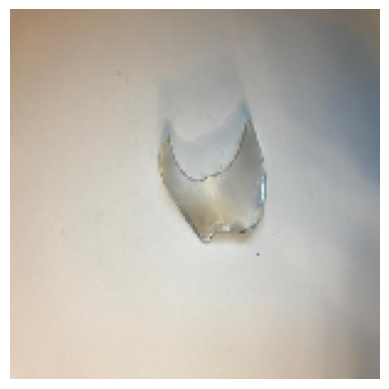

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Predicted Category: glass
♻ Recyclable


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Make sure this path is correct (from Step 2)

# 1. Load the image
img = image.load_img(img_path, target_size=(150,150), color_mode='rgb') # Changed target_size to (150,150)

# 2. Show the image
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Convert to array
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)

# 5. Class list
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]
print("Predicted Category:", predicted_class)

# 6. Recycling logic
recyclable = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
if predicted_class in recyclable:
    print("♻ Recyclable")
else:
    print("❌ Non-recyclable")

In [ ]:
import os
print(os.listdir("/content/dataset-resized/cardboard"))

['cardboard41.jpg', 'cardboard250.jpg', 'cardboard175.jpg', 'cardboard112.jpg', 'cardboard316.jpg', 'cardboard100.jpg', 'cardboard180.jpg', 'cardboard395.jpg', 'cardboard264.jpg', 'cardboard23.jpg', 'cardboard82.jpg', 'cardboard262.jpg', 'cardboard39.jpg', 'cardboard95.jpg', 'cardboard208.jpg', 'cardboard31.jpg', 'cardboard396.jpg', 'cardboard255.jpg', 'cardboard357.jpg', 'cardboard154.jpg', 'cardboard2.jpg', 'cardboard85.jpg', 'cardboard193.jpg', 'cardboard367.jpg', 'cardboard147.jpg', 'cardboard319.jpg', 'cardboard224.jpg', 'cardboard133.jpg', 'cardboard13.jpg', 'cardboard225.jpg', 'cardboard59.jpg', 'cardboard233.jpg', 'cardboard383.jpg', 'cardboard184.jpg', 'cardboard373.jpg', 'cardboard283.jpg', 'cardboard26.jpg', 'cardboard274.jpg', 'cardboard93.jpg', 'cardboard155.jpg', 'cardboard284.jpg', 'cardboard97.jpg', 'cardboard56.jpg', 'cardboard204.jpg', 'cardboard291.jpg', 'cardboard115.jpg', 'cardboard358.jpg', 'cardboard240.jpg', 'cardboard143.jpg', 'cardboard331.jpg', 'cardboard217.

In [ ]:
img_path = "/content/dataset-resized/cardboard/cardboard175.jpg"

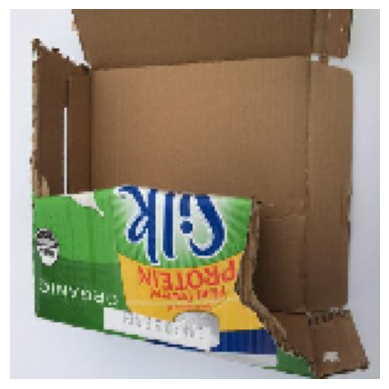

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted Category: cardboard
♻ Recyclable


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Make sure this path is correct (from Step 2)

# 1. Load the image
img = image.load_img(img_path, target_size=(150,150), color_mode='rgb') # Changed target_size to (150,150)

# 2. Show the image
plt.imshow(img)
plt.axis("off")
plt.show()

# 3. Convert to array
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# 4. Predict
prediction = model.predict(img_array)

# 5. Class list
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

predicted_class = class_names[np.argmax(prediction)]
print("Predicted Category:", predicted_class)

# 6. Recycling logic
recyclable = ['cardboard', 'glass', 'metal', 'paper', 'plastic']
if predicted_class in recyclable:
    print("♻ Recyclable")
else:
    print("❌ Non-recyclable")

### Reuse, renew, and let waste fade away...

